# Линейный дискриминант Фишера

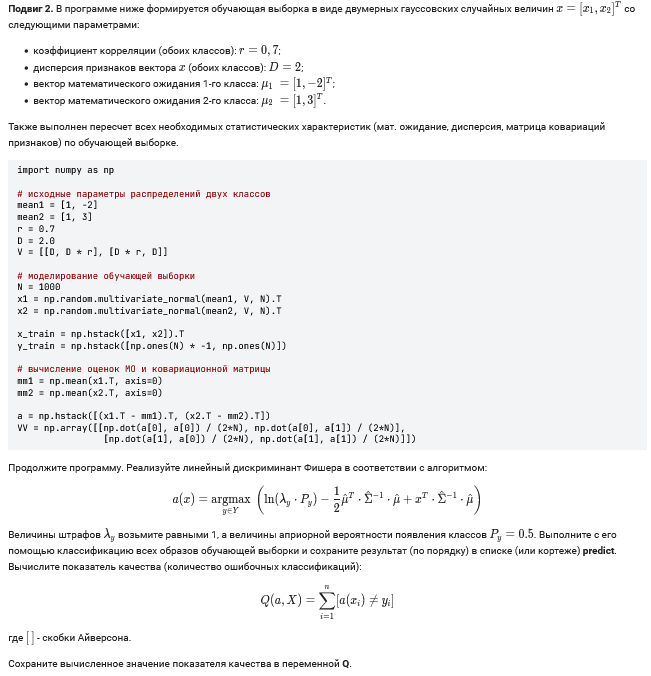

In [6]:
import numpy as np

np.random.seed(0)

# исходные параметры распределений двух классов
mean1 = [1, -2]
mean2 = [1, 3]
r = 0.7
D = 2.0
V = [[D, D * r], [D * r, D]]

# моделирование обучающей выборки
N = 1000
x1 = np.random.multivariate_normal(mean1, V, N).T
x2 = np.random.multivariate_normal(mean2, V, N).T

x_train = np.hstack([x1, x2]).T
y_train = np.hstack([np.ones(N) * -1, np.ones(N)])

# вычисление оценок МО и ковариационной матрицы
mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)

a = np.hstack([(x1.T - mm1).T, (x2.T - mm2).T])
VV = np.array([[np.dot(a[0], a[0]) / (2*N), np.dot(a[0], a[1]) / (2*N)],
                [np.dot(a[1], a[0]) / (2*N), np.dot(a[1], a[1]) / (2*N)]])

# здесь продолжайте программу

# параметры для гауссовского байесовского классификатора
Py1, L1 = 0.5, 1  # вероятности появления классов
Py2, L2 = 1 - Py1, 1  # и величины штрафов неверной классификации

b = lambda x, mm, lm, py: np.log(lm * py) - 0.5 * mm.T @ np.linalg.inv(VV) @ mm + x.T @ np.linalg.inv(VV) @ mm

br1 = np.array([b(x, mm1, L1, Py1) for x in x_train])
br2 = np.array([b(x, mm2, L2, Py2) for x in x_train])

predict = np.where(br1 > br2, -1, 1)

Q = np.sum(predict != y_train)

print(predict)
print(Q)

[-1 -1 -1 ...  1  1  1]
8


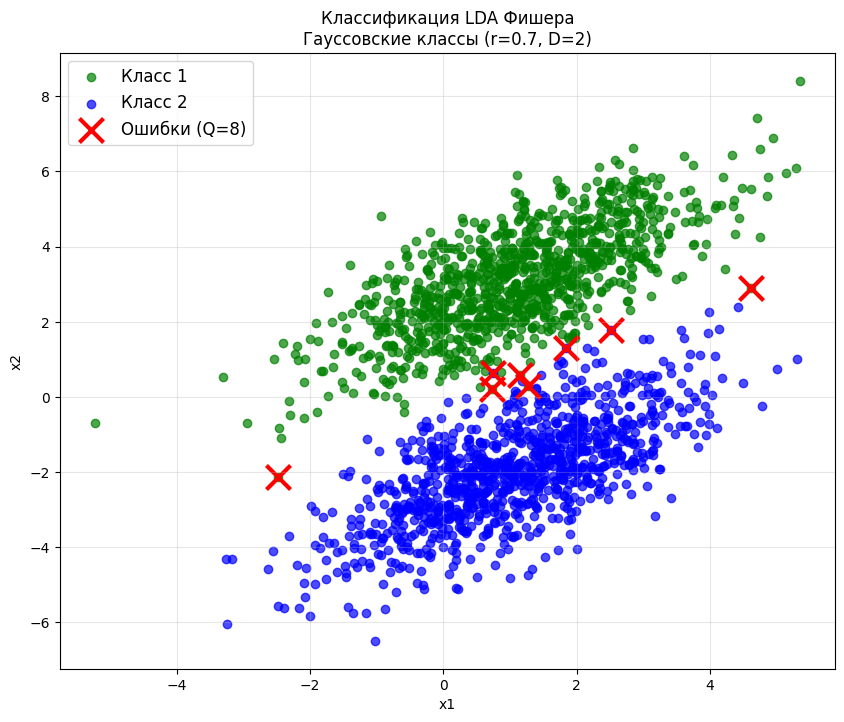

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], c='green', label="Класс 1", alpha=0.7)
plt.scatter(x_train[y_train == -1][:, 0], x_train[y_train == -1][:, 1], c='blue', label="Класс 2", alpha=0.7)
plt.scatter(x_train[y_train != predict][:, 0], x_train[y_train != predict][:, 1], c='red', marker='x', s=300, linewidth=3, label=f'Ошибки (Q={Q})')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Классификация LDA Фишера\nГауссовские классы (r=0.7, D=2)')
plt.legend(fontsize=12, frameon=True)
plt.grid(True, alpha=0.3)

plt.show()

In [30]:
import numpy as np

np.random.seed(0)

# исходные параметры распределений двух классов
mean1 = np.array([1, -2, 0])
mean2 = np.array([1, 3, 1])
r = 0.7
D = 2.0
V = [[D, D * r, D*r*r], [D*r, D, D*r], [D*r*r, D*r, D]]

# моделирование обучающей выборки
N = 1000
x1 = np.random.multivariate_normal(mean1, V, N).T
x2 = np.random.multivariate_normal(mean2, V, N).T

x_train = np.hstack([x1, x2]).T
y_train = np.hstack([np.zeros(N), np.ones(N)])

# здесь вычисляйте векторы математических ожиданий и ковариационную матрицу по выборке x1, x2

# параметры для линейного дискриминанта Фишера
Py1, L1 = 0.5, 1  # вероятности появления классов
Py2, L2 = 1 - Py1, 1  # и величины штрафов неверной классификации

# здесь продолжайте программу

# вычисление оценок МО и ковариационной матрицы
mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)

a = np.hstack([(x1.T - mm1).T, (x2.T - mm2).T])
VV = np.cov(a)

alf = lambda mm: np.linalg.inv(VV) @ mm
btf = lambda mm, lm, py: np.log(lm * py) - 0.5 * mm.T @ np.linalg.inv(VV) @ mm

a = lambda x, al, bt: x.T @ al + bt

alpha1 = alf(mm1)
alpha2 = alf(mm2)

beta1 = btf(mm1, L1, Py1)
beta2 = btf(mm2, L2, Py2)

ar1 = np.array([a(x, alpha1, beta1) for x in x_train])
ar2 = np.array([a(x, alpha2, beta2) for x in x_train])

predict = np.where(ar1 > ar2, 0, 1)
Q = np.sum(predict != y_train, axis=0)

print(predict)
print(Q)

[0 0 0 ... 1 1 1]
4


In [33]:
import numpy as np

np.random.seed(0)

# исходные параметры распределений двух классов
mean1 = np.array([1, -2])
mean2 = np.array([-3, -1])
mean3 = np.array([1, 2])

r = 0.5
D = 1.0
V = [[D, D * r], [D*r, D]]

# моделирование обучающей выборки
N = 1000
x1 = np.random.multivariate_normal(mean1, V, N).T
x2 = np.random.multivariate_normal(mean2, V, N).T
x3 = np.random.multivariate_normal(mean3, V, N).T

x_train = np.hstack([x1, x2, x3]).T
y_train = np.hstack([np.zeros(N), np.ones(N), np.ones(N) * 2])

# здесь вычисляйте векторы математических ожиданий и ковариационную матрицу по выборке x1, x2, x3

# параметры для линейного дискриминанта Фишера
Py1, Py2, Py3 = 0.2, 0.4, 0.4
L1, L2, L3 = 1, 1, 1

mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)
mm3 = np.mean(x3.T, axis=0)

a = np.hstack([(x1.T - mm1).T, (x2.T - mm2).T, (x3.T - mm3).T])
VV = np.cov(a)

# здесь продолжайте программу
alf = lambda mm: np.linalg.inv(VV) @ mm
btf = lambda mm, lm, py: np.log(lm * py) - 0.5 * mm.T @ np.linalg.inv(VV) @ mm

a = lambda x, al, bt: x.T @ al + bt

alphas = [alf(mm1), alf(mm2), alf(mm3)]
betas = [btf(mm1, L1, Py1), btf(mm2, L2, Py2), btf(mm3, L3, Py3)]

ar1 = np.array([a(x, alphas[0], betas[0]) for x in x_train])
ar2 = np.array([a(x, alphas[1], betas[1]) for x in x_train])
ar3 = np.array([a(x, alphas[2], betas[2]) for x in x_train])

predict = np.argmax([ar1, ar2, ar3], axis=0)
Q = np.sum(predict != y_train, axis=0)

print(predict)
print(Q)

[0 0 0 ... 2 2 2]
60


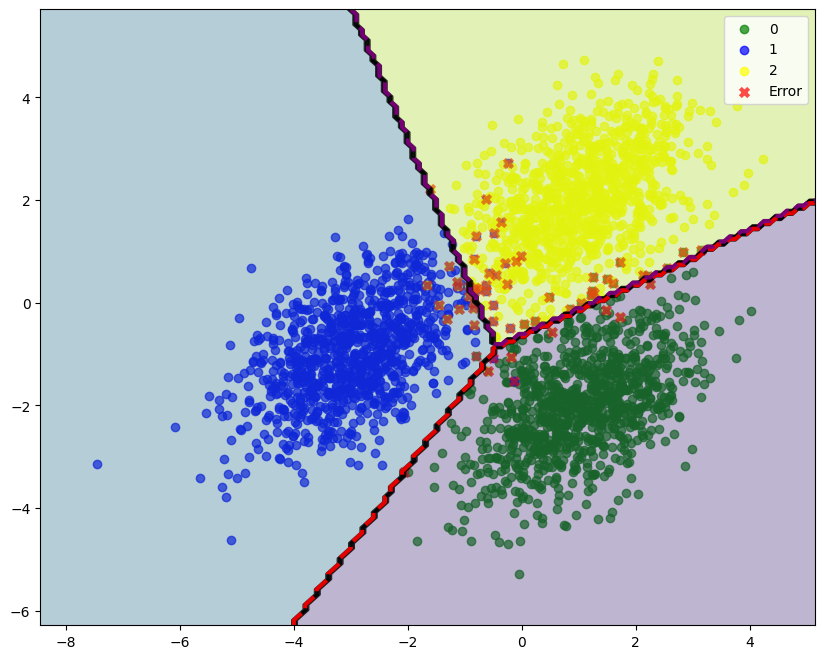

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], c='green', label="0", alpha=0.7)
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], c='blue', label="1", alpha=0.7)
plt.scatter(x_train[y_train == 2][:, 0], x_train[y_train == 2][:, 1], c='yellow', label="2", alpha=0.7)

plt.scatter(x_train[y_train != predict][:, 0], x_train[y_train != predict][:, 1], c='red', marker="x", linewidths=3, label="Error", alpha=0.7)

# === РЕШАЮЩИЕ ГРАНИЦЫ (для 3 классов) ===
def lda_predict(X):
    """Предсказание для сетки точек"""
    ar1_grid = np.array([a(x, alphas[0], betas[0]) for x in X])
    ar2_grid = np.array([a(x, alphas[1], betas[1]) for x in X])
    ar3_grid = np.array([a(x, alphas[2], betas[2]) for x in X])
    return np.argmax([ar1_grid, ar2_grid, ar3_grid], axis=0)

# Создаем сетку
x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), 
                     np.arange(y_min, y_max, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]

# Предсказания на сетке
Z = lda_predict(grid).reshape(xx.shape)

# Заливка областей (прозрачная)
plt.contourf(xx, yy, Z, alpha=0.35, cmap='viridis', levels=3)

# Разделяющие линии (контуры)
plt.contour(xx, yy, Z, colors='black', linewidths=2, alpha=0.8)
plt.contour(xx, yy, Z, levels=[0.5, 1.5], colors=['red', 'purple'], 
            linewidths=3, linestyles='--', alpha=0.9)

plt.legend()

plt.show()

In [40]:
import numpy as np

np.random.seed(0)

# исходные параметры распределений трех классов
r1 = 0.7
D1 = 3.0
mean1 = [1, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.5
D2 = 2.0
mean2 = [-3, -1]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

r3 = 0.3
D3 = 1.0
mean3 = [1, 2]
V3 = [[D3, D3 * r3], [D3 * r3, D3]]

# моделирование обучающей выборки
N = 1000
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T
x3 = np.random.multivariate_normal(mean3, V3, N).T

x_train = np.hstack([x1, x2, x3]).T
y_train = np.hstack([np.zeros(N), np.ones(N), np.ones(N) * 2])

mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)
mm3 = np.mean(x3.T, axis=0)

a = (x1.T - mm1).T
VV1 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

a = (x2.T - mm2).T
VV2 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

a = (x3.T - mm3).T
VV3 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

# параметры для гауссовского байесовского классификатора
Py1, Py2, Py3 = 0.2, 0.5, 0.3
L1, L2, L3 = 1, 1, 1

# здесь продолжайте программу
b = lambda x, v, m, l, py: np.log(l * py) - 0.5 * (x - m) @ np.linalg.inv(v) @ (x - m).T - 0.5 * np.log(np.linalg.det(v))

br1 = np.array([b(x, VV1, mm1, L1, Py1) for x in x_train])
br2 = np.array([b(x, VV2, mm2, L2, Py2) for x in x_train])
br3 = np.array([b(x, VV3, mm3, L3, Py3) for x in x_train])

predict = np.argmax([br1, br2, br3], axis=0)

Q = np.sum(predict != y_train)

print(predict)
print(Q)

[0 1 0 ... 2 2 2]
189
